# TODOs
- gender neutral version
- very clear structure that makes it easy to map to for participants, embeddings ec

In [1]:
from shared.main import * 
from embedding_models import *

from typing import Dict
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
import umap
import plotly.graph_objects as go

colors = {"affil": "blue", "power": "red"}
alpha  = {+1: 0.90, -1: 0.30}
label  = {("affil", +1): "Affil +1", ("affil", -1): "Affil -1",
          ("power", +1): "Power +1", ("power", -1): "Power -1"}

# embed the options for each decision
- probably need to strip names and other features to make this as fair as possible

In [ ]:
df_plot = df_long[df_long["dim"].notna()].copy()
E = np.vstack(df_plot["emb"].to_numpy())  # (N, D)


#--------------------- Contrast vectors

def _unit(v, eps=1e-12):
    n = np.linalg.norm(v)
    return v / (n + eps)

# Per-decision delta vectors: (pos - neg) within each decision
delta_rows = []
for dnum, g in df_plot.groupby(["decision_num", "dim"]):
    decision_num, dim = dnum
    gpos = g[g["sign"] == 1]
    gneg = g[g["sign"] == -1]
    v = gpos["emb"].iloc[0] - gneg["emb"].iloc[0]
    delta_rows.append({
        "decision_num": int(decision_num),
        "dim": dim,
        "delta": np.asarray(v, float),
        "delta_unit": _unit(np.asarray(v, float)),
        "delta_norm": float(np.linalg.norm(v)),
    })
df_deltas = pd.DataFrame(delta_rows)

# Global axes: mean of deltas per dimension (optionally unit-normalize)
axes = {}
for dim in ["affil", "power"]:
    V = np.vstack(df_deltas.loc[df_deltas["dim"] == dim, "delta"].to_numpy())
    axes[dim] = {
        "axis": V.mean(axis=0),
        "axis_unit": _unit(V.mean(axis=0)),
        "n_decisions": int((df_deltas["dim"] == dim).sum())
    }
v_affil = axes["affil"]["axis_unit"]
v_power = axes["power"]["axis_unit"]

# check orthogonality / entanglement
cos_ap = float(np.dot(v_affil, v_power))
print("n_decisions:", {k: axes[k]["n_decisions"] for k in axes})
print("cosine(affil_axis, power_axis) =", cos_ap)

# add coordinates to each option (project embeddings onto axes)
df_plot["coord_affil"] = [float(np.dot(e, v_affil)) for e in df_plot["emb"]]
df_plot["coord_power"] = [float(np.dot(e, v_power)) for e in df_plot["emb"]]

n_decisions: {'affil': 30, 'power': 30}
cosine(affil_axis, power_axis) = 0.3137689939859821


<h1 align='center'> Similarity between choices </h1>

<Axes: >

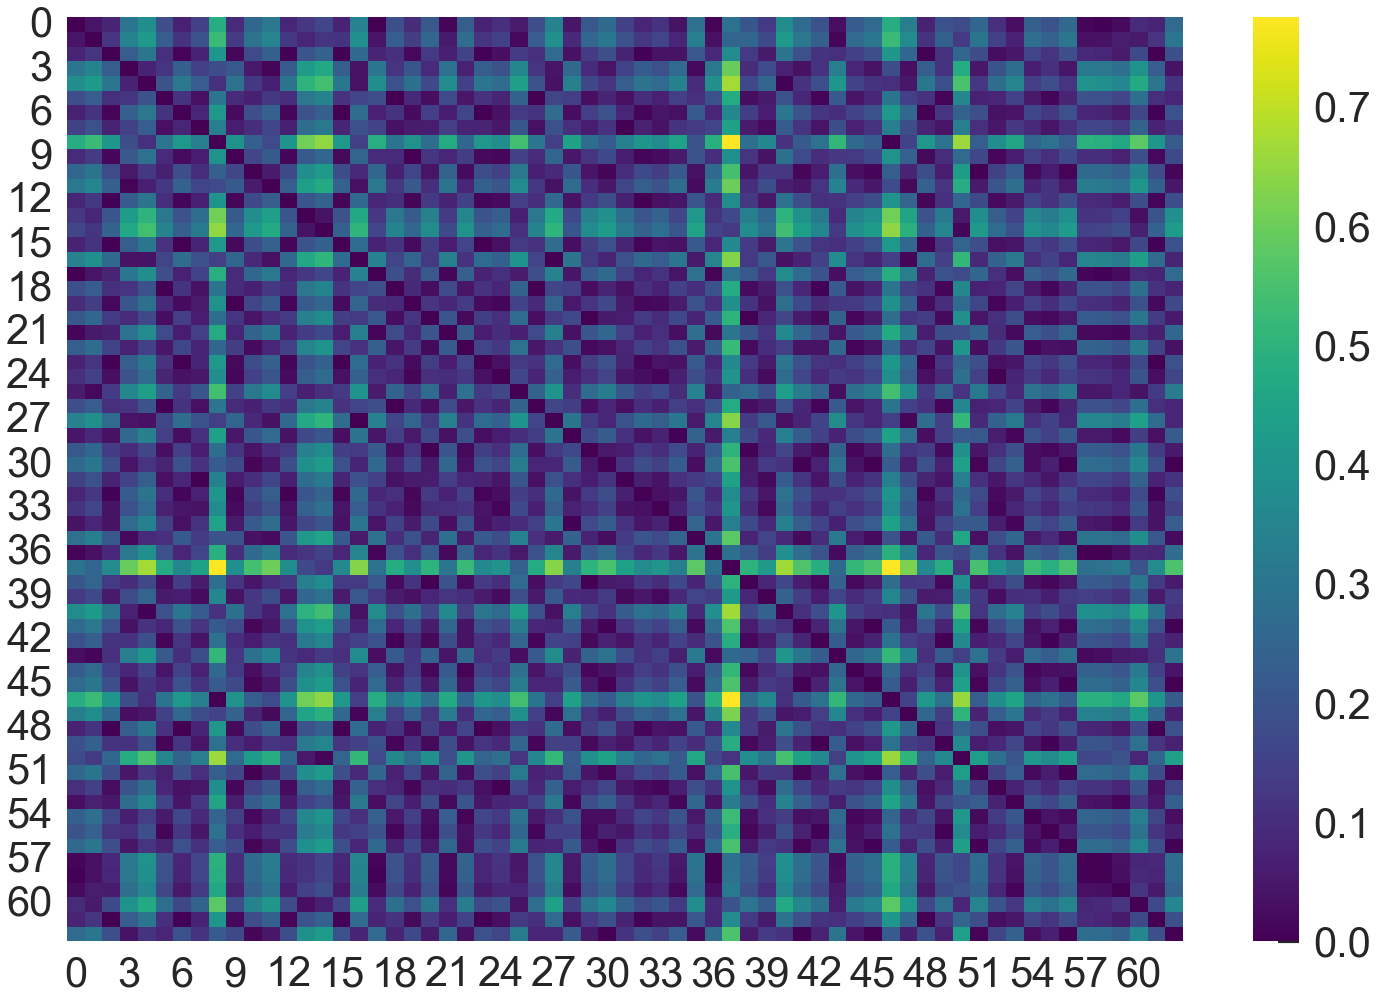

In [44]:
cos_dists = pairwise_distances(df_cos['cos'].values[:,np.newaxis], metric='euclidean')
sns.heatmap(cos_dists, cmap='viridis')

<Axes: xlabel='cos', ylabel='Density'>

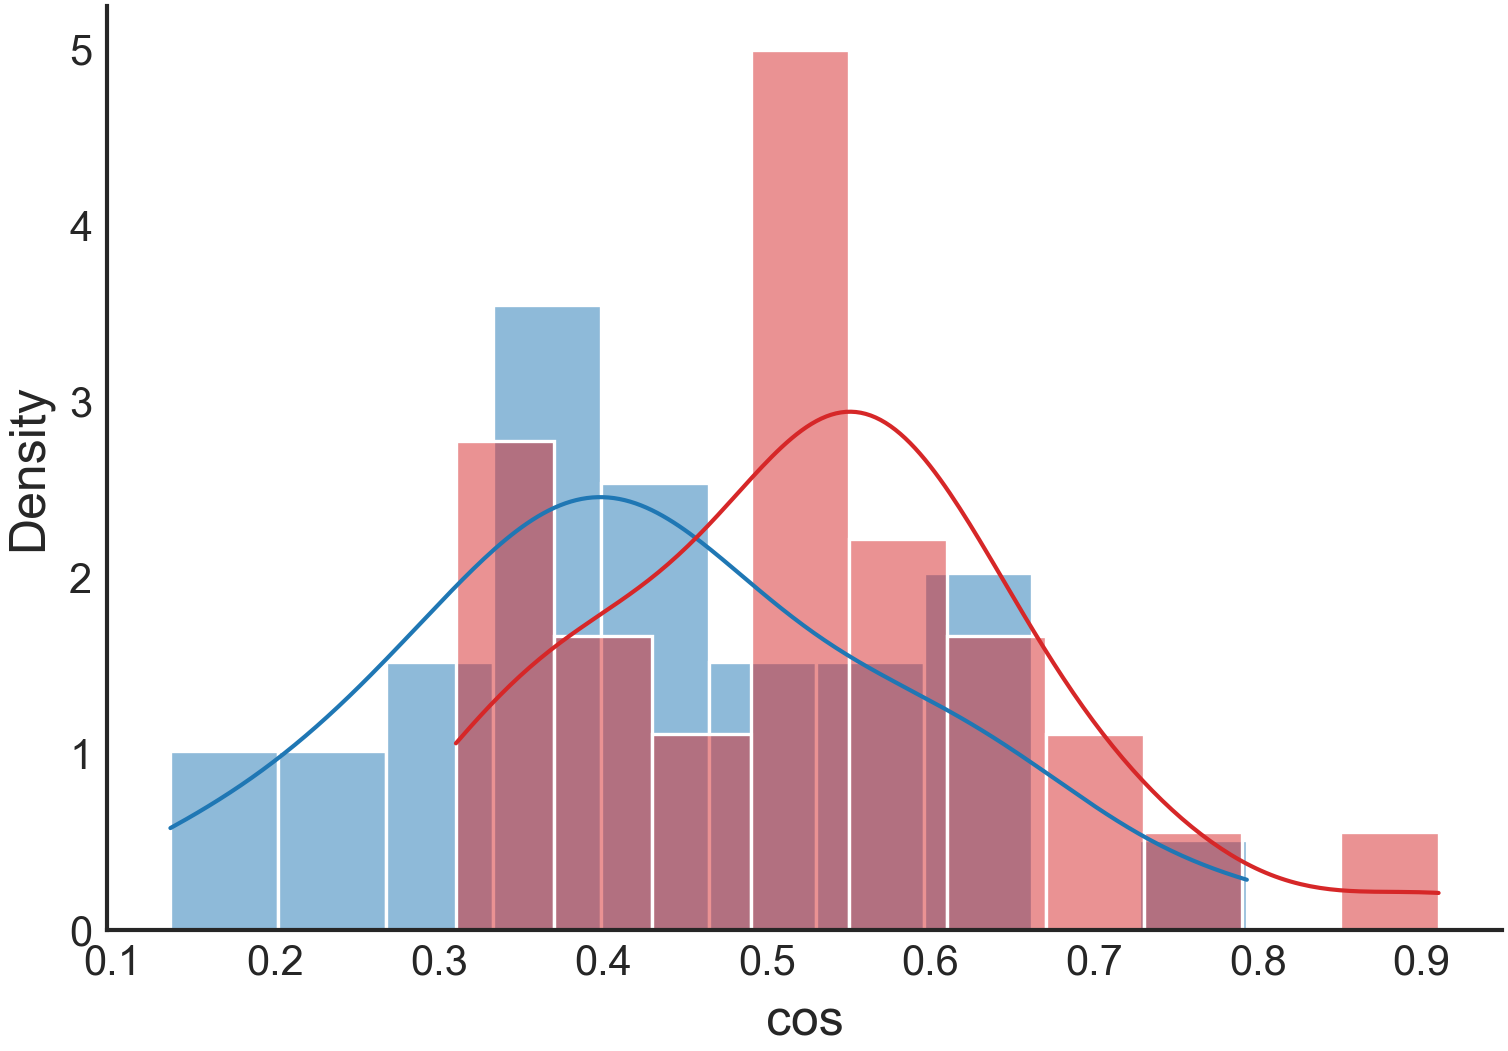

In [42]:
df_cos_affil = df_cos[df_cos['dimension']=='affil']
df_cos_power = df_cos[df_cos['dimension']=='power']

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df_cos_affil['cos'], color="tab:blue", label='Affil', kde=True, stat='density', bins=10)
sns.histplot(df_cos_power['cos'], color="tab:red", label='Power', kde=True, stat='density', bins=10)

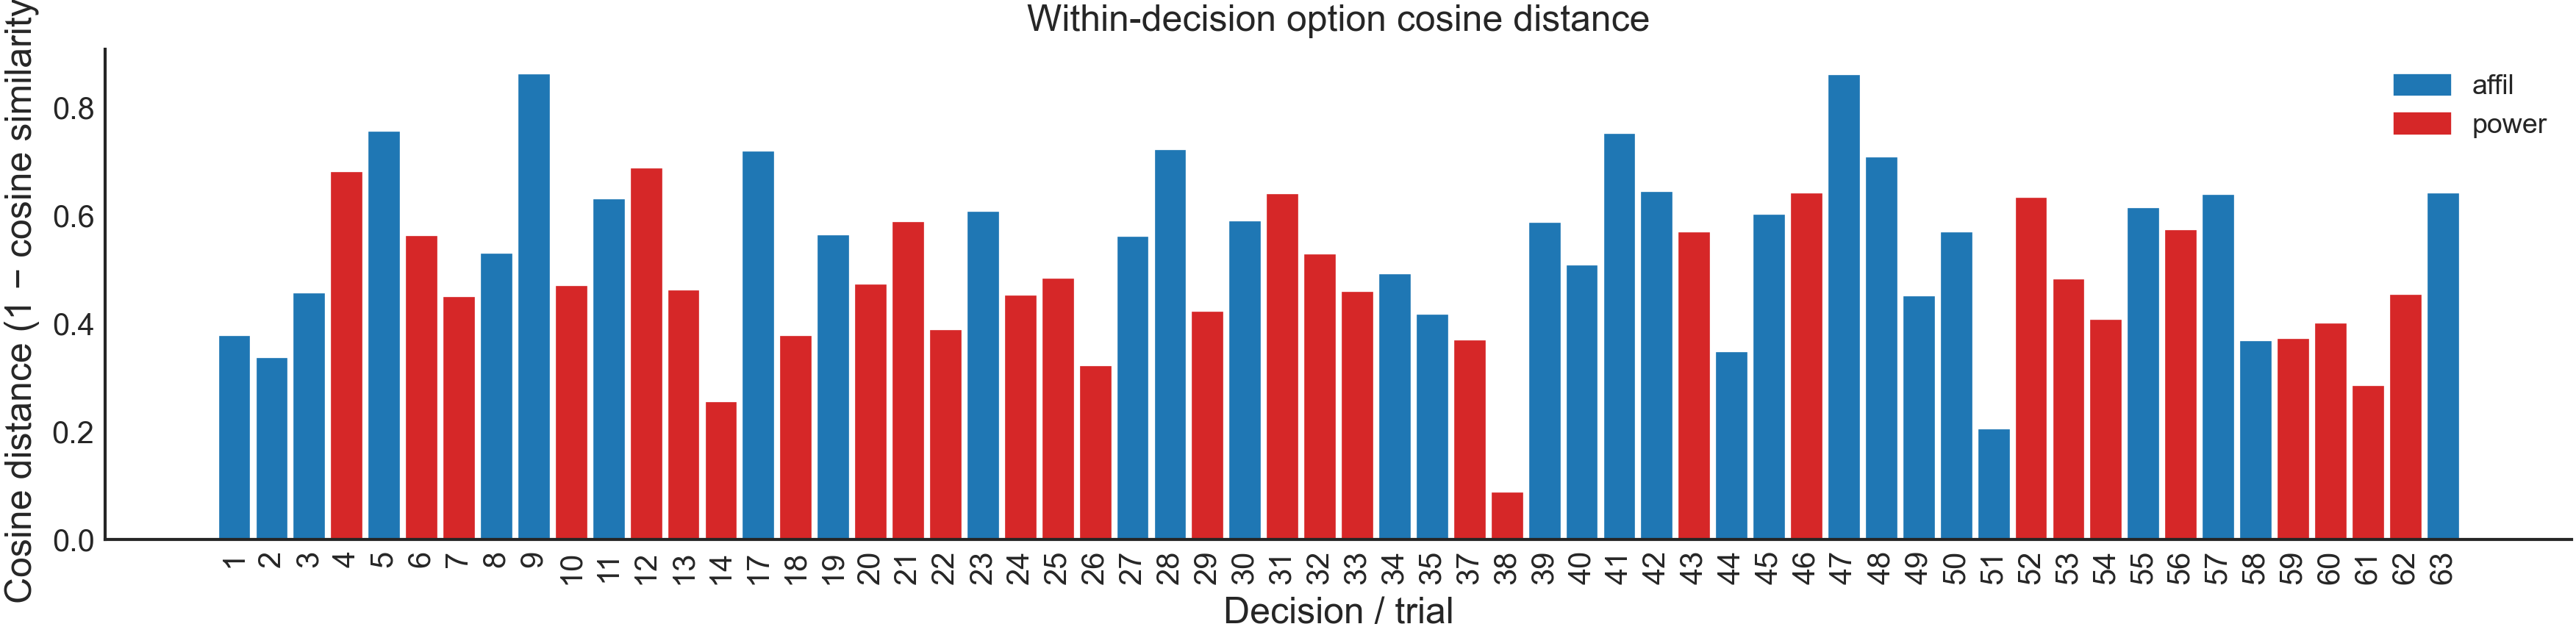

In [31]:
df_cos["cos_dist"] = 1.0 - df_cos["cos"].astype(float)
if "dim_label" not in df_cos.columns:
    dim = df_cos["dimension"].astype(str).str.lower()
    df_cos["dim_label"] = np.where(dim.str.contains("aff"), "affil",
                           np.where(dim.str.contains("pow") | dim.str.contains("dom"), "power",
                           dim))
df_cos = df_cos[df_cos["dim_label"].isin(["affil", "power"])].copy()
df_cos = df_cos.sort_values("decision_num").reset_index(drop=True)

# --- Plot
x = np.arange(len(df_cos))

plt.figure(figsize=(12, 3.2))
plt.bar(x, df_cos["cos_dist"].to_numpy(), color=np.where(df_cos["dim_label"].eq("affil"), "tab:blue", "tab:red"), width=0.9)
plt.xticks(x, df_cos["decision_num"].to_numpy(), rotation=90)
plt.ylabel("Cosine distance (1 − cosine similarity)")
plt.xlabel("Decision / trial")
plt.title("Within-decision option cosine distance")

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color="tab:blue", label="affil"),
                    Patch(color="tab:red",  label="power")],
           frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

<h1 align='center'> model-free </h1>

## PCA geometry

Effective dim (PR): 48.5
PCs for 50/80/90/95% variance: 18 50 71 88


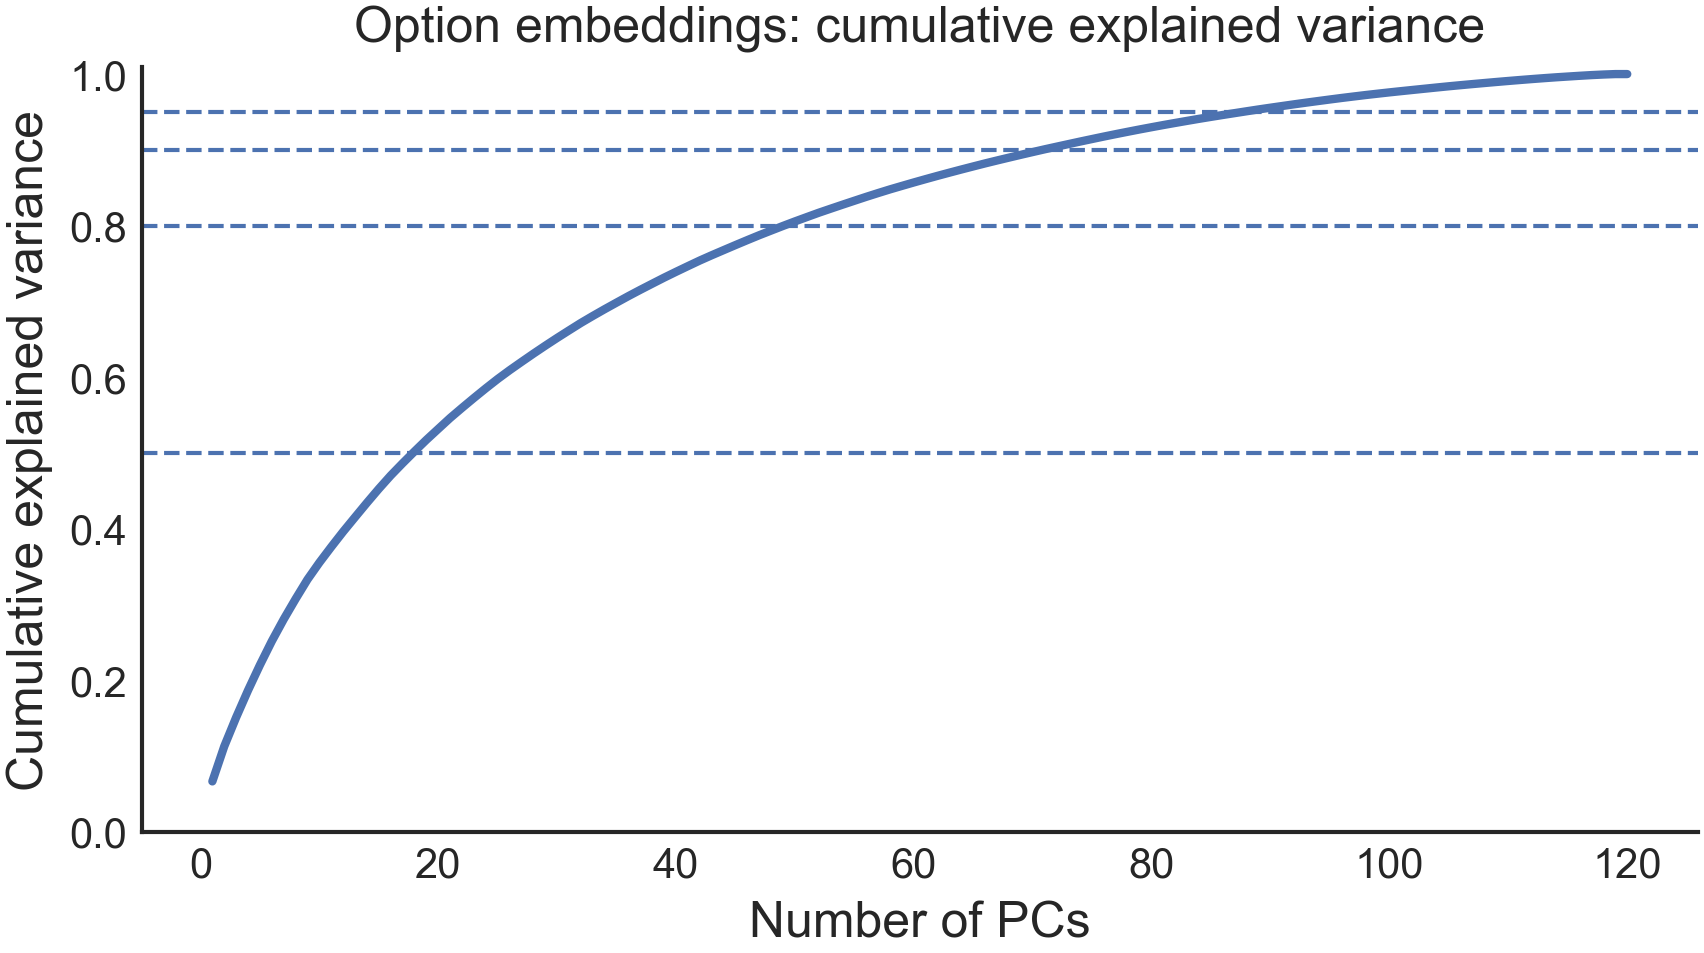

In [8]:
#------------------- run PCA

pca     = PCA().fit(E)
eigvals = pca.explained_variance_
vr      = pca.explained_variance_ratio_         # fraction of total variance per PC
cum_vr  = np.cumsum(vr)
eff_dim = (eigvals.sum() ** 2) / np.sum(eigvals ** 2)

def pcs_for(thr):
    return int(np.searchsorted(cum_vr, thr) + 1)
print(f"Effective dim (PR): {eff_dim:.1f}")
print("PCs for 50/80/90/95% variance:",
      pcs_for(0.50), pcs_for(0.80), pcs_for(0.90), pcs_for(0.95))

# ---- Cumulative explained variance
plt.figure(figsize=(6, 3.5))
plt.plot(np.arange(1, len(cum_vr)+1), cum_vr, color="C0", lw=2)
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.title("Option embeddings: cumulative explained variance")
plt.ylim(0, 1.01)
plt.axhline(0.50, linestyle="--")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.tight_layout()
plt.show()

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ----------------------------
# helpers
# ----------------------------

def rgba(color_name, a):
    if color_name == "blue":
        return f"rgba(0, 0, 255, {a})"
    if color_name == "red":
        return f"rgba(255, 0, 0, {a})"
    return f"rgba(0, 0, 0, {a})"

# ----------------------------
# PCA fit on option embeddings
# ----------------------------

E = np.vstack(df_plot["emb"].to_numpy())  # (N, D)
pca3 = PCA(n_components=3, random_state=0)
Y3 = pca3.fit_transform(E)  # (N, 3)

# ----------------------------
# compute per-decision deltas in ORIGINAL space
# ----------------------------

vec_rows = []
for (dnum, dim), g in df_plot.groupby(["decision_num", "dim"]):
    gpos = g[g["sign"] == 1]
    gneg = g[g["sign"] == -1]
    if len(gpos) != 1 or len(gneg) != 1:
        continue

    e_pos = gpos["emb"].iloc[0]
    e_neg = gneg["emb"].iloc[0]

    base = 0.5 * (e_pos + e_neg)         # midpoint anchor
    delta = (e_pos - e_neg)              # + minus -
    vec_rows.append((int(dnum), dim, base, delta))

# project bases and endpoints to PCA space
bases = np.vstack([b for _, _, b, _ in vec_rows])
ends  = np.vstack([b + d for _, _, b, d in vec_rows])  # endpoint in original space

B3 = pca3.transform(bases)   # (M, 3)
E3 = pca3.transform(ends)    # (M, 3)

# optional: scale arrows so they are visually comparable
# (PCA coordinates can make arrows too long/short depending on variance)
scale_arrows = 1.0  # try 0.5 or 2.0 if needed
E3_scaled = B3 + scale_arrows * (E3 - B3)

# ----------------------------
# Plotly subplots
# ----------------------------

fig = make_subplots(
    rows=1, cols=2,
    horizontal_spacing=0.08,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("Option embeddings", "Within-decision difference vectors")
)

SHOW_TEXT_ALWAYS = False

# ---- panel 1: points
for dim in ["affil", "power"]:
    for s in [-1, +1]:
        m   = (df_plot["dim"].to_numpy() == dim) & (df_plot["sign"].to_numpy() == s)
        col = rgba(colors[dim], alpha[s])
        mode = "markers+text" if SHOW_TEXT_ALWAYS else "markers"

        fig.add_trace(
            go.Scatter3d(
                x=Y3[m, 0], y=Y3[m, 1], z=Y3[m, 2],
                mode=mode,
                name=f"{dim} {s:+d}",
                text=df_plot.loc[m, "opt_text"],
                hovertext=df_plot.loc[m, "opt_text"],
                hoverinfo="text",
                marker=dict(size=6, color=col, line=dict(color="black", width=1)),
                showlegend=True,
            ),
            row=1, col=1
        )

# ---- panel 2: vectors
# First, add line segments by dimension
for dim in ["affil", "power"]:
    idx = [i for i, (_, d, _, _) in enumerate(vec_rows) if d == dim]
    xs, ys, zs = [], [], []
    for i in idx:
        xs += [B3[i, 0], E3_scaled[i, 0], None]
        ys += [B3[i, 1], E3_scaled[i, 1], None]
        zs += [B3[i, 2], E3_scaled[i, 2], None]

    fig.add_trace(
        go.Scatter3d(
            x=xs, y=ys, z=zs,
            mode="lines",
            name=f"{dim} delta",
            line=dict(width=4, color=rgba(colors[dim], 0.9)),
            hoverinfo="skip",
            showlegend=True,
        ),
        row=1, col=2
    )

# arrowheads using cones (one cone per vector)
use_cones = True
if use_cones and len(vec_rows) > 0:
    for dim in ["affil", "power"]:
        idx = [i for i, (_, d, _, _) in enumerate(vec_rows) if d == dim]
        u = (E3_scaled[idx, 0] - B3[idx, 0])
        v = (E3_scaled[idx, 1] - B3[idx, 1])
        w = (E3_scaled[idx, 2] - B3[idx, 2])
        fig.add_trace(
            go.Cone(
                x=E3_scaled[idx, 0],
                y=E3_scaled[idx, 1],
                z=E3_scaled[idx, 2],
                u=u, v=v, w=w,
                anchor="tip",
                sizemode="scaled",
                sizeref=0.25,  # adjust arrowhead size
                showscale=False,
                colorscale=[[0, rgba(colors[dim], 1.0)], [1, rgba(colors[dim], 1.0)]],
                name=f"{dim} delta head",
                hoverinfo="skip",
                showlegend=False,
            ),
            row=1, col=2
        )

# layout
fig.update_layout(
    title="PCA: option embeddings and within-decision contrast vectors",
    legend=dict(itemsizing="constant"),
    margin=dict(l=0, r=0, t=60, b=0),
    width=1400, height=600,
)

for scene_id in ["scene", "scene2"]:
    fig.update_layout(**{
        scene_id: dict(
            xaxis_title="PC-1",
            yaxis_title="PC-2",
            zaxis_title="PC-3",
        )
    })

fig.show()


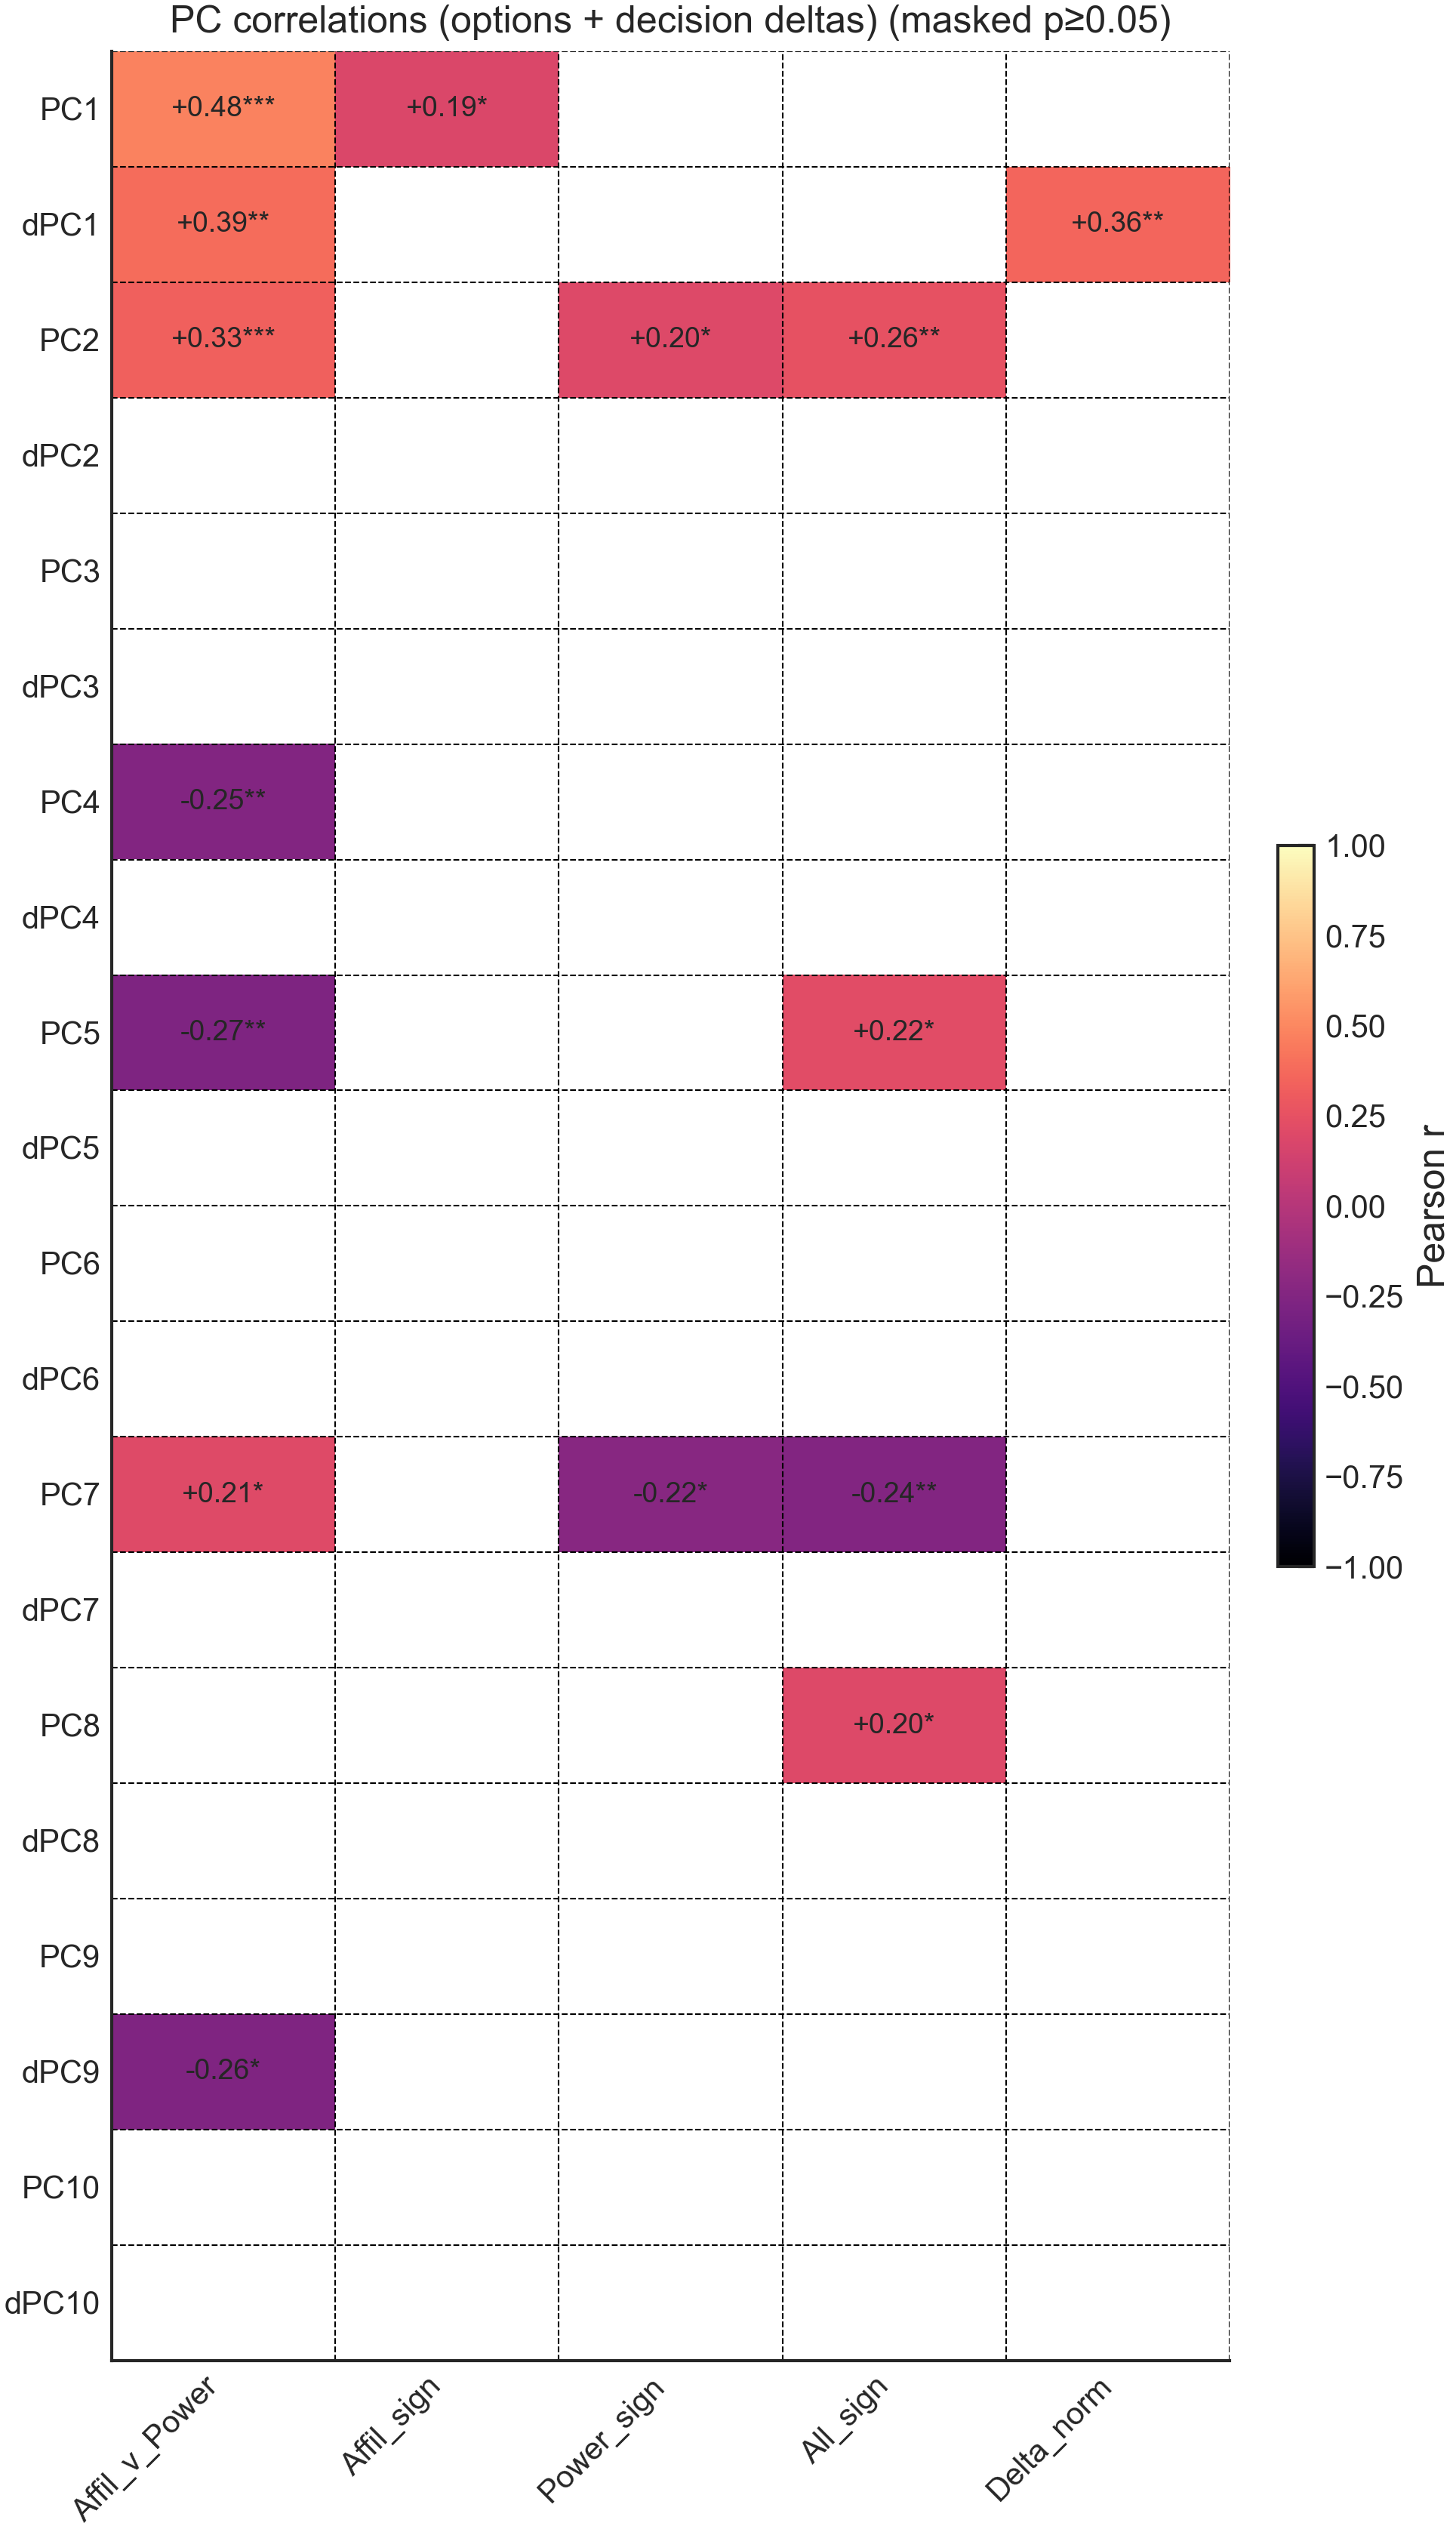

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# ----------------------------
# helpers
# ----------------------------
def _pc_num_any(name):
    # handles "PC1" or "dPC1"
    s = str(name).replace("dPC", "PC")
    return int(s.replace("PC", ""))

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# ============================
# Inputs expected:
#   df_plot: option-level long df with ["decision_num","dim","sign","dimension","y_affil","y_power","emb", ...]
# ============================
E = np.vstack(df_plot["emb"].to_numpy())  # (N, D)

# ============================
# PCA on option embeddings
# ============================
pca = PCA(n_components=10, random_state=0)
Y = pca.fit_transform(E)
pc_cols = [f"PC{i+1}" for i in range(Y.shape[1])]

df_pc = pd.concat(
    [df_plot.reset_index(drop=True),
     pd.DataFrame(Y, columns=pc_cols)],
    axis=1
)

# ============================
# Option-level features
# ============================
df_pc["is_affil"] = (df_pc["dimension"] == "affil").astype(int)
df_pc["is_power"] = (df_pc["dimension"] == "power").astype(int)

df_pc["sign_affil"] = df_pc["y_affil"]  # ∈ {+1, −1, 0}
df_pc["sign_power"] = df_pc["y_power"]  # ∈ {+1, −1, 0}
df_pc["sign_any"]   = df_pc[["y_affil", "y_power"]].sum(axis=1)

# ============================
# Delta vectors per decision (+1 - -1), projected into PCA space
# ============================
delta_rows = []
for (dnum, dim), g in df_plot.groupby(["decision_num", "dim"]):
    gpos = g[g["sign"] == 1]
    gneg = g[g["sign"] == -1]
    if len(gpos) != 1 or len(gneg) != 1:
        continue

    e_pos = gpos["emb"].iloc[0]
    e_neg = gneg["emb"].iloc[0]
    delta = np.asarray(e_pos - e_neg, float)

    delta_rows.append({
        "decision_num": int(dnum),
        "dim": dim,
        "delta": delta,
        "delta_norm": float(np.linalg.norm(delta)),
        "delta_is_affil": int(dim == "affil"),   # <-- the key delta-appropriate feature
    })

df_delta = pd.DataFrame(delta_rows)

# Transform deltas into PCA space (PCA is linear, so this is valid)
# Note: PCA transform includes centering; for direction vectors, this is still a consistent
# linear mapping into the PC coordinate system used for Y.
D = np.vstack(df_delta["delta"].to_numpy())            # (n_decisions, D)
dY = pca.transform(D)                                 # (n_decisions, 10)
dpc_cols = [f"dPC{i+1}" for i in range(dY.shape[1])]
df_delta = pd.concat([df_delta, pd.DataFrame(dY, columns=dpc_cols)], axis=1)

# ============================
# Correlations: (A) option-level PCs vs option-level targets
# ============================
targets_opt = {
    "is_affil":   "Affil_v_Power",
    "sign_affil": "Affil_sign",
    "sign_power": "Power_sign",
    "sign_any":   "All_sign",
}

rows = []
for pc in pc_cols:
    x = df_pc[pc].to_numpy()
    for var, label in targets_opt.items():
        y = df_pc[var].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 5:
            continue
        r, p = pearsonr(x[m], y[m])
        rows.append({"PC": pc, "Target": label, "r": r, "p": p})

corr_opt = pd.DataFrame(rows)

# ============================
# Correlations: (B) delta-level dPCs vs delta-appropriate targets
# ============================
targets_delta = {
    "delta_is_affil": "Affil_v_Power",  # same conceptual contrast, but for deltas
    "delta_norm":     "Delta_norm",
}

rows = []
for dpc in dpc_cols:
    x = df_delta[dpc].to_numpy()
    for var, label in targets_delta.items():
        y = df_delta[var].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 5:
            continue
        r, p = pearsonr(x[m], y[m])
        rows.append({"PC": dpc, "Target": label, "r": r, "p": p})

corr_delta = pd.DataFrame(rows)

# Combine into one heatmap table
corr_df = pd.concat([corr_opt, corr_delta], ignore_index=True)

r_mat = corr_df.pivot(index="PC", columns="Target", values="r")
p_mat = corr_df.pivot(index="PC", columns="Target", values="p")

# ============================
# Ordering
# ============================
# order rows as PC1..PC10 then dPC1..dPC10
row_order = sorted(r_mat.index, key=_pc_num_any)
r_mat = r_mat.loc[row_order]
p_mat = p_mat.loc[r_mat.index, r_mat.columns]

# order columns (x-axis)
x_order = ["Affil_v_Power", "Affil_sign", "Power_sign", "All_sign", "Delta_norm"]
x_order = [c for c in x_order if c in r_mat.columns]
r_mat = r_mat[x_order]
p_mat = p_mat[x_order]

# ============================
# OPTIONAL: mask insignificant correlations
# ============================
mask_nonsig = True
alpha_level = 0.05

r_plot = r_mat.mask(p_mat >= alpha_level) if mask_nonsig else r_mat

stars = p_mat.applymap(p_to_stars)
if mask_nonsig:
    stars = stars.mask(p_mat >= alpha_level, "")

# ============================
# Plot heatmap
# ============================
fig, ax = plt.subplots(figsize=(0.75 * r_mat.shape[1] + 3, 0.45 * r_mat.shape[0] + 2.5))

cmap = plt.cm.get_cmap("magma").copy()
cmap.set_bad(color="white")

im = ax.imshow(r_plot.values, aspect="auto", vmin=-1, vmax=1, cmap=cmap)

ax.set_xticks(np.arange(r_mat.shape[1]))
ax.set_xticklabels(r_mat.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(r_mat.shape[0]))
ax.set_yticklabels(r_mat.index)

title = "PC correlations (options + decision deltas)"
if mask_nonsig:
    title += f" (masked p≥{alpha_level:g})"
ax.set_title(title)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Pearson r")

for i in range(r_mat.shape[0]):
    for j in range(r_mat.shape[1]):
        r = r_plot.values[i, j]
        if np.isnan(r):
            txt = ""
        else:
            txt = f"{r:+.2f}{stars.values[i, j]}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=9)

ax.set_xticks(np.arange(-.5, r_mat.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-.5, r_mat.shape[0], 1), minor=True)
ax.grid(which="minor", color="black", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()


<h1 align='center'> model-based </h1>

## test for axes

## learn the axes

letting them correlate somewhat improves the recovery

In [ ]:
def _unit(v, eps=1e-12):
    v = np.asarray(v, float).ravel()
    n = np.linalg.norm(v)
    return v / (n + eps)

def _gram_schmidt(u, v, eps=1e-12):
    """
    Make v orthogonal to u, return (u_unit, v_orth_unit).
    """
    u = _unit(u, eps=eps)
    v = np.asarray(v, float).ravel()
    v_orth = v - (v @ u) * u
    return u, _unit(v_orth, eps=eps)

def fit_social_axes_from_option_embeddings(decision_df, embd_dict, *, orthogonalize=True):
    """
    decision_df columns expected (your snippet):
      decision_num, dimension, opt1_text, opt2_text, opt1_affil, opt2_affil, opt1_power, opt2_power

    embd_dict loaded from your npz:
      embd_dict[dnum]["opt1"] / ["opt2"] -> embedding vector (normalized if you saved normalized)
      embd_dict["info"] exists too; ignored.
    """
    rows = []
    for r in decision_df.itertuples(index=False):
        dnum = int(r.decision_num)

        for which in ("opt1", "opt2"):
            # embedding
            if dnum not in embd_dict or which not in embd_dict[dnum]:
                continue
            e = np.asarray(embd_dict[dnum][which], float).ravel()

            # signed labels (these should be -1/+1 or 0)
            ya = getattr(r, f"{which}_affil")
            yp = getattr(r, f"{which}_power")

            rows.append({
                "decision_num": dnum,
                "which": which,
                "dimension": getattr(r, "dimension"),
                "y_affil": float(ya) if np.isfinite(ya) else np.nan,
                "y_power": float(yp) if np.isfinite(yp) else np.nan,
                "emb": e,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No rows found. Check that decision_df decision_num matches embd_dict keys.")

    E = np.vstack(df["emb"].to_numpy())
    D = E.shape[1]

    # --- affiliation axis: use only +/-1 (drop zeros and NaNs)
    mA = np.isfinite(df["y_affil"].to_numpy())
    mA &= np.isin(df["y_affil"].to_numpy(), [-1, 1])
    EA = E[mA]
    yA = df.loc[mA, "y_affil"].to_numpy().astype(float)
    axis_affil = _unit(EA[yA == 1].mean(axis=0) - EA[yA == -1].mean(axis=0))

    # --- power axis
    mP = np.isfinite(df["y_power"].to_numpy())
    mP &= np.isin(df["y_power"].to_numpy(), [-1, 1])
    EP = E[mP]
    yP = df.loc[mP, "y_power"].to_numpy().astype(float)
    axis_power = _unit(EP[yP == 1].mean(axis=0) - EP[yP == -1].mean(axis=0))

    # --- enforce orthogonality (often desirable given task design)
    if orthogonalize:
        axis_affil, axis_power = _gram_schmidt(axis_affil, axis_power)

    # --- quick diagnostics: how well does sign(axis·emb) match the ±1 label?
    def _acc(Esub, ysub, axis):
        # predict sign; treat 0 as +1 (rare exact zeros)
        s = Esub @ axis
        yhat = np.where(s >= 0, 1.0, -1.0)
        return float(np.mean(yhat == ysub))

    diag = {
        "n_total_options": int(E.shape[0]),
        "embed_dim": int(D),
        "n_affil_labeled_pm1": int(EA.shape[0]),
        "n_power_labeled_pm1": int(EP.shape[0]),
        "train_acc_affil_sign": _acc(EA, yA, axis_affil),
        "train_acc_power_sign": _acc(EP, yP, axis_power),
        "cos_sim_axes": float(axis_affil @ axis_power),
    }

    return {
        "axis_affil": axis_affil,
        "axis_power": axis_power,
        "df": df,       # long-form rows; useful for debugging / plotting
        "diagnostics": diag,
    }

res = fit_social_axes_from_option_embeddings(decision_df, embd_dict, orthogonalize=True)
axis_affil = res["axis_affil"]
axis_power = res["axis_power"]
diag = res["diagnostics"]
acc_affil = diag["train_acc_affil_sign"]
acc_power = diag["train_acc_power_sign"]
print(f"Affiliation axis train ±1 sign accuracy: {acc_affil:.3f}")
print(f"Power axis train ±1 sign accuracy: {acc_power:.3f}")
axis_orth = axis_affil @ axis_power
print(f"Cosine similarity between axes = {axis_orth:.3f}")

### leave one decision out tests

Can the semantic space correctly order the +1 vs −1 option for each decision along the task-relevant dimension?

dot(e_+, axis) > dot(e_-, axis) 

In [ ]:
from scipy.stats import ttest_1samp, binomtest, ttest_rel

def fit_axes_excluding_decisions(df, exclude_decisions, *, orthogonalize):
    """
    df: long dataframe returned earlier (one row per option)
    exclude_decisions: set of decision_num to leave out
    """

    keep = ~df["decision_num"].isin(exclude_decisions)
    D = len(df.iloc[0]["emb"])

    # ---- affiliation axis
    mA = (
        keep &
        df["y_affil"].isin([-1, 1])
    )
    EA = np.vstack(df.loc[mA, "emb"])
    yA = df.loc[mA, "y_affil"].to_numpy()

    axis_affil = _unit(EA[yA == 1].mean(axis=0) -
                       EA[yA == -1].mean(axis=0))

    # ---- power axis
    mP = (
        keep &
        df["y_power"].isin([-1, 1])
    )
    EP = np.vstack(df.loc[mP, "emb"])
    yP = df.loc[mP, "y_power"].to_numpy()

    axis_power = _unit(EP[yP == 1].mean(axis=0) -
                       EP[yP == -1].mean(axis=0))

    if orthogonalize:
        axis_affil, axis_power = _gram_schmidt(axis_affil, axis_power)

    return axis_affil, axis_power

def lodo_decision_level_test(df, *, orthogonalize=True):
    """
    Returns per-decision correctness and summary statistics.
    """

    results = []

    for dnum, rows in df.groupby("decision_num"):
        rows = rows.reset_index(drop=True)

        # identify which dimension this decision targets
        if rows["y_affil"].isin([-1, 1]).any():
            dim = "affil"
            label_col = "y_affil"
        elif rows["y_power"].isin([-1, 1]).any():
            dim = "power"
            label_col = "y_power"
        else:
            continue

        # fit axes leaving this decision out
        axis_affil, axis_power = fit_axes_excluding_decisions(
            df, exclude_decisions={dnum}, orthogonalize=orthogonalize
        )
        axis = axis_affil if dim == "affil" else axis_power

        # extract +1 and -1 option embeddings
        pos = rows.loc[rows[label_col] == 1, "emb"].values[0]
        neg = rows.loc[rows[label_col] == -1, "emb"].values[0]

        correct = (pos @ axis) > (neg @ axis)

        results.append({
            "decision_num": dnum,
            "dimension": dim,
            "correct": int(correct),
        })

    res = np.array([r["correct"] for r in results])
    acc = res.mean()
    n = len(res)
    k = res.sum()

    # ---- statistics
    binom_p = binomtest(k, n, p=0.5, alternative="greater").pvalue

    # permutation test (sign flip)
    n_perm = 10000
    perm_acc = []
    for _ in range(n_perm):
        flips = np.random.choice([0, 1], size=n)
        perm_acc.append(np.mean(res ^ flips))
    perm_p = np.mean(np.array(perm_acc) >= acc)

    return {
        "n_decisions": n,
        "accuracy": acc,
        "binomial_p": binom_p,
        "perm_p": perm_p,
        "by_decision": results,
    }

def lodo_2d_coordinate_recovery(df, *, orthogonalize=True):
    """
    Returns per-decision 2D displacement (Δaffil, Δpower)
    using leave-one-decision-out axis fitting.
    """

    rows_out = []

    for dnum, rows in df.groupby("decision_num"):
        rows = rows.reset_index(drop=True)

        # determine relevant dimension
        if rows["y_affil"].isin([-1, 1]).any():
            dim = "affil"
            label_col = "y_affil"
        elif rows["y_power"].isin([-1, 1]).any():
            dim = "power"
            label_col = "y_power"
        else:
            continue

        # fit axes excluding this decision
        axis_affil, axis_power = fit_axes_excluding_decisions(
            df,
            exclude_decisions={dnum},
            orthogonalize=orthogonalize
        )

        # embeddings
        e_pos = rows.loc[rows[label_col] == 1, "emb"].values[0]
        e_neg = rows.loc[rows[label_col] == -1, "emb"].values[0]
        delta = e_pos - e_neg

        da = float(delta @ axis_affil)
        dp = float(delta @ axis_power)

        rows_out.append({
            "decision_num": dnum,
            "dimension": dim,
            "delta_affil": da,
            "delta_power": dp,
        })

    return pd.DataFrame(rows_out)

def summarize_2d_recovery(df2d):
    is_affil = df2d["dimension"] == "affil"
    is_power = df2d["dimension"] == "power"

    # correct-axis signal
    correct = np.concatenate([
        df2d.loc[is_affil, "delta_affil"].values,
        df2d.loc[is_power, "delta_power"].values,
    ])

    # off-axis leakage
    off = np.concatenate([
        df2d.loc[is_affil, "delta_power"].values,
        df2d.loc[is_power, "delta_affil"].values,
    ])

    return correct, off

def lodo_2d_coordinate_recovery(df, *, orthogonalize=True):
    rows_out = []

    for dnum, rows in df.groupby("decision_num"):
        rows = rows.reset_index(drop=True)

        # determine relevant dimension for this decision
        if rows["y_affil"].isin([-1, 1]).any():
            dim = "affil"
            label_col = "y_affil"
        elif rows["y_power"].isin([-1, 1]).any():
            dim = "power"
            label_col = "y_power"
        else:
            continue

        # fit axes excluding this decision
        axis_affil, axis_power = fit_axes_excluding_decisions(
            df, exclude_decisions={dnum}, orthogonalize=orthogonalize
        )

        e_pos = rows.loc[rows[label_col] == 1, "emb"].values[0]
        e_neg = rows.loc[rows[label_col] == -1, "emb"].values[0]
        delta = e_pos - e_neg

        rows_out.append({
            "decision_num": dnum,
            "dimension": dim,
            "delta_affil": float(delta @ axis_affil),
            "delta_power": float(delta @ axis_power),
        })

    return pd.DataFrame(rows_out)

def summarize_2d_recovery(df2d):
    is_affil = df2d["dimension"].eq("affil").to_numpy()
    is_power = df2d["dimension"].eq("power").to_numpy()

    correct = np.concatenate([
        df2d.loc[is_affil, "delta_affil"].to_numpy(),
        df2d.loc[is_power, "delta_power"].to_numpy(),
    ])

    off = np.concatenate([
        df2d.loc[is_affil, "delta_power"].to_numpy(),
        df2d.loc[is_power, "delta_affil"].to_numpy(),
    ])

    return correct.astype(float), off.astype(float)

def run_lodo_semantic_axis_suite(df, *, n_perm=10000):
    """
    Runs:
      (A) Decision-level LODO ordering test
      (B) 2D coordinate recovery test
    for both correlated (orthogonalize=False) and orthogonalized (True) axes.

    Prints a compact summary and returns a dict of full results.
    """

    out = {}

    for orth in (False, True):
        label = "CORRELATED" if not orth else "ORTHOGONALIZED"
        print("\n" + "="*72)
        print(f"{label} AXES (orthogonalize={orth})")
        print("="*72)

        # --- (A) decision-level test
        dec = lodo_decision_level_test(df, orthogonalize=orth)
        out[(orth, "decision_level")] = dec

        n = dec["n_decisions"]
        acc = float(dec["accuracy"])
        k = int(round(acc * n))
        p_binom = float(dec["binomial_p"])
        p_perm = float(dec["perm_p"]) if np.isfinite(dec["perm_p"]) else np.nan

        print("Decision-level LODO ordering")
        print(f"  n={n:3d} | acc={acc:.3f} ({k}/{n}) | binom p={p_binom:.2e} | perm p<{max(p_perm, 1/n_perm):.1e}" if p_perm == 0 else
              f"  n={n:3d} | acc={acc:.3f} ({k}/{n}) | binom p={p_binom:.2e} | perm p={p_perm:.2e}")

        # --- (B) 2D recovery test
        df2d = lodo_2d_coordinate_recovery(df, orthogonalize=orth)
        correct, off = summarize_2d_recovery(df2d)

        # Correct axis > 0
        t_c, p_c = ttest_1samp(correct, 0.0, alternative="greater")

        # Off axis ~ 0 (two-sided)
        t_o, p_o = ttest_1samp(off, 0.0)

        # Specificity: correct > |off| (paired)
        t_s, p_s = ttest_rel(correct, np.abs(off), alternative="greater")

        out[(orth, "2d")] = {
            "df2d": df2d,
            "correct": correct,
            "off": off,
            "t_correct_gt0": float(t_c), "p_correct_gt0": float(p_c),
            "t_off_ne0": float(t_o),     "p_off_ne0": float(p_o),
            "t_spec_correct_gt_abs_off": float(t_s),
            "p_spec_correct_gt_abs_off": float(p_s),
            "mean_correct": float(np.mean(correct)),
            "mean_off": float(np.mean(off)),
        }

        print("2D coordinate recovery (Δ = e(+1) − e(−1))")
        print(f"  mean(correct)={np.mean(correct): .4f} | t={t_c: .3f} | p={p_c:.2e}   [H1: correct-axis > 0]")
        print(f"  mean(off)    ={np.mean(off): .4f} | t={t_o: .3f} | p={p_o:.2e}   [H2: off-axis ≈ 0]")
        print(f"  specificity: correct > |off| | t={t_s: .3f} | p={p_s:.2e}")

    return out

suite = run_lodo_semantic_axis_suite(res["df"])

In [ ]:
def build_decision_delta_dataset(df_long):
    """
    df_long: your long df with columns:
      decision_num, y_affil, y_power, emb
    Returns:
      X: (N, D) delta embeddings
      Y: (N, 2) targets: [affil, power] with 1 on relevant dim else 0
      meta: DataFrame with decision_num and dimension
    """
    X, Y, meta_rows = [], [], []

    for dnum, rows in df_long.groupby("decision_num"):
        rows = rows.reset_index(drop=True)

        if rows["y_affil"].isin([-1, 1]).any():
            dim = "affil"
            label_col = "y_affil"
            y = np.array([1.0, 0.0])
        elif rows["y_power"].isin([-1, 1]).any():
            dim = "power"
            label_col = "y_power"
            y = np.array([0.0, 1.0])
        else:
            continue

        e_pos = rows.loc[rows[label_col] == 1, "emb"].values[0]
        e_neg = rows.loc[rows[label_col] == -1, "emb"].values[0]
        delta = np.asarray(e_pos, float) - np.asarray(e_neg, float)

        X.append(delta)
        Y.append(y)
        meta_rows.append({"decision_num": int(dnum), "dimension": dim})

    X = np.vstack(X)
    Y = np.vstack(Y)
    meta = pd.DataFrame(meta_rows)
    return X, Y, meta

def lodo_joint_2d_axes(df_long, lam=1.0):
    """
    Leave-one-decision-out for joint 2D axis learning.
    Returns per-decision predictions and summary stats for:
      - on-target > 0
      - off-target ~ 0
      - specificity: on-target > |off-target|
      - and a simple decision classification accuracy (argmax)
    """
    X, Y, meta = build_decision_delta_dataset(df_long)
    n, D = X.shape

    Yhat = np.zeros_like(Y)

    for i in range(n):
        train = np.ones(n, dtype=bool)
        train[i] = False

        W = fit_ridge_multioutput(X[train], Y[train], lam=lam)
        Yhat[i] = X[i] @ W

    # On-target and off-target components
    is_affil = meta["dimension"].eq("affil").to_numpy()
    is_power = meta["dimension"].eq("power").to_numpy()

    on = np.concatenate([Yhat[is_affil, 0], Yhat[is_power, 1]])
    off = np.concatenate([Yhat[is_affil, 1], Yhat[is_power, 0]])

    # Stats
    t_on, p_on = ttest_1samp(on, 0.0, alternative="greater")
    t_off, p_off = ttest_1samp(off, 0.0)  # want ~0
    t_spec, p_spec = ttest_rel(on, np.abs(off), alternative="greater")

    # Decision classification accuracy: does model put larger value on correct dim?
    # (affil decision -> yhat_affil > yhat_power; power decision -> reverse)
    correct_class = np.zeros(n, dtype=bool)
    correct_class[is_affil] = Yhat[is_affil, 0] > Yhat[is_affil, 1]
    correct_class[is_power] = Yhat[is_power, 1] > Yhat[is_power, 0]
    acc = float(np.mean(correct_class))

    per_dec = meta.copy()
    per_dec["yhat_affil"] = Yhat[:, 0]
    per_dec["yhat_power"] = Yhat[:, 1]
    per_dec["correct_dim_wins"] = correct_class.astype(int)

    summary = {
        "n_decisions": int(n),
        "lam": float(lam),
        "acc_dim_wins": acc,
        "mean_on": float(np.mean(on)),
        "mean_off": float(np.mean(off)),
        "mean_abs_off": float(np.mean(np.abs(off))),
        "t_on_gt0": float(t_on), "p_on_gt0": float(p_on),
        "t_off_ne0": float(t_off), "p_off_ne0": float(p_off),
        "t_spec_on_gt_abs_off": float(t_spec), "p_spec_on_gt_abs_off": float(p_spec),
    }

    return per_dec, summary

def fit_ridge_multioutput(X, Y, lam=1.0):
    """
    Multi-output ridge regression (closed form).

    Solves:  W = argmin_W ||XW - Y||^2 + lam ||W||^2

    X: (N, D) design matrix
    Y: (N, K) targets (here K=2)
    lam: ridge penalty (scalar)

    Returns:
      W: (D, K) weight matrix; each column is an axis/direction in embedding space.
    """
    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    N, D = X.shape

    # (D,D)
    A = X.T @ X + lam * np.eye(D)

    # (D,K)
    B = X.T @ Y

    # Solve A W = B
    W = np.linalg.solve(A, B)
    return W

def fit_final_joint_axes(df_long, lam=1.0, normalize=True):
    X, Y, meta = build_decision_delta_dataset(df_long)
    W = fit_ridge_multioutput(X, Y, lam=lam)  # (D,2)

    axis_affil = W[:, 0]
    axis_power = W[:, 1]

    if normalize:
        axis_affil = axis_affil / (np.linalg.norm(axis_affil) + 1e-12)
        axis_power = axis_power / (np.linalg.norm(axis_power) + 1e-12)

    return axis_affil, axis_power, {"lam": lam, "n_decisions": len(meta)}


In [ ]:
# df_long is res["df"] from your earlier pipeline
df_long = res["df"]

for lam in [0.1, 1.0, 10.0, 100.0]:
    per_dec, summ = lodo_joint_2d_axes(df_long, lam=lam)
    print("\n" + "-"*72)
    print(f"JOINT 2D RIDGE (lam={lam})")
    print("-"*72)
    print(f"n={summ['n_decisions']} | dim-win acc={summ['acc_dim_wins']:.3f}")
    print(f"mean(on)={summ['mean_on']:.4f} | t={summ['t_on_gt0']:.3f} | p={summ['p_on_gt0']:.2e}   [want >0]")
    print(f"mean(off)={summ['mean_off']:.4f} | t={summ['t_off_ne0']:.3f} | p={summ['p_off_ne0']:.2e}   [want ~0]")
    print(f"specificity: on > |off| | t={summ['t_spec_on_gt_abs_off']:.3f} | p={summ['p_spec_on_gt_abs_off']:.2e}")

axis_affil_opt, axis_power_opt, info = fit_final_joint_axes(df_long, lam=1.0)
